# Protein Expression Dotplot
Dotplot showing cell types vs protein channels.
- **Dot size** = fraction of cells expressing the marker (above a threshold)
- **Dot colour** = mean expression level

In [1]:
import sys
sys.path.append('../../../phenotyping')

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from phenotyping_utils import generate_anndata_from_cell_table

In [3]:
adata = generate_anndata_from_cell_table(
    cell_table_path='/Users/linus/Library/CloudStorage/pr/projects/cellStates/∆Tissue/IMC_TNBC_analysis/CellTable_CleanCohort/updated_cell_table_Ki67.csv',
    biosamples_path='/Users/linus/Library/CloudStorage/pr/projects/cellStates/∆Tissue/IMC_TNBC_analysis/CellTable_CleanCohort/CleanCohort_Metadata.csv'
)

/Users/linus/opt/miniconda3/envs/imc_analysis/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [4]:
# Clean up cell type labels (consistent with Cell Counts notebook)
adata.obs['Pixie'] = adata.obs['Pixie'].cat.rename_categories({
    'B cell': 'Unassigned',
    'Macrophage': 'Macrophage M1',
    'Monocyte': 'NonCl Monocyte'
})
adata = adata[adata.obs['Pixie'] != 'Unassigned'].copy()
adata.obs['Pixie'] = adata.obs['Pixie'].cat.remove_unused_categories()

In [5]:
# Markers used for phenotyping
markers = [
    'CD3', 'CD4', 'CD8a', 'FOXP3', 'CD45', 'CD45RO', 'Granzyme-B',
    'CD20', 'CD14', 'CD16', 'CD68', 'CD163', 'CD11b', 'HLA-DR-DQ-DP',
    'Pan-keratin', 'E-Cadherin', 'Beta-Catenin', 'B7-H4',
    'Alpha-SMA', 'Vimentin', 'CD31', 'CD44', 'CD107a', 'CD366'
]
# Keep only markers present in the data
markers = [m for m in markers if m in adata.var_names]

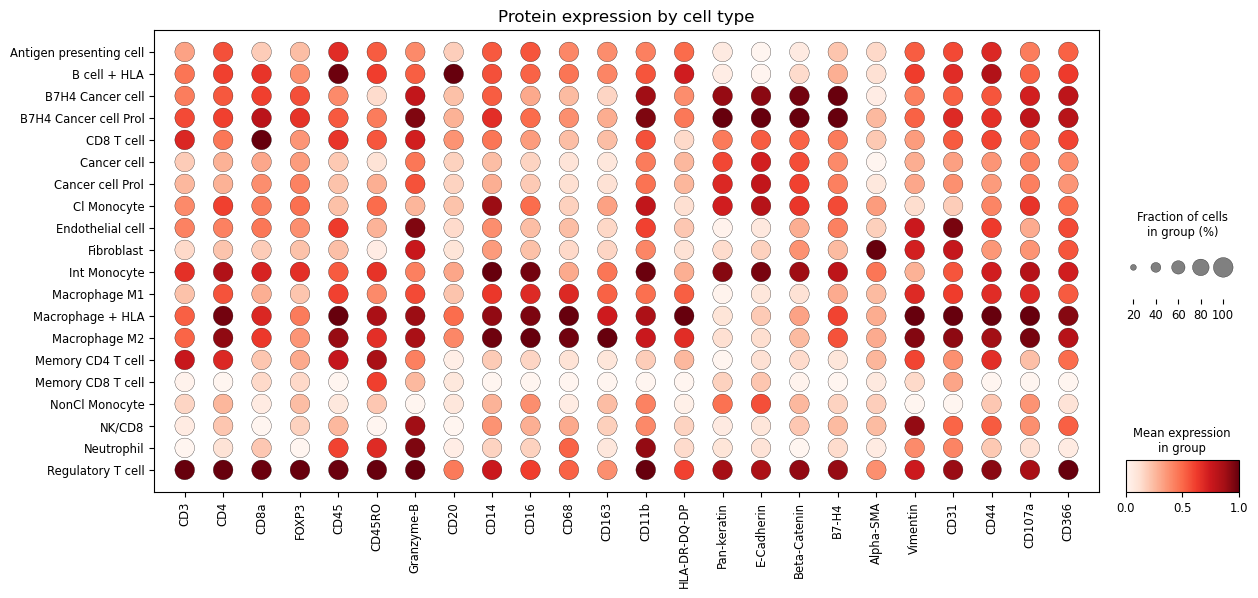

In [6]:
sc.pl.dotplot(
    adata,
    var_names=markers,
    groupby='Pixie',
    standard_scale='var',
    title='Protein expression by cell type',
    figsize=(14, 6),
    save='_protein_expression.png'
)

### Dotplot using raw (unnormalized) expression
Uses the raw counts stored in `adata.raw` before log-transform and quantile normalisation.

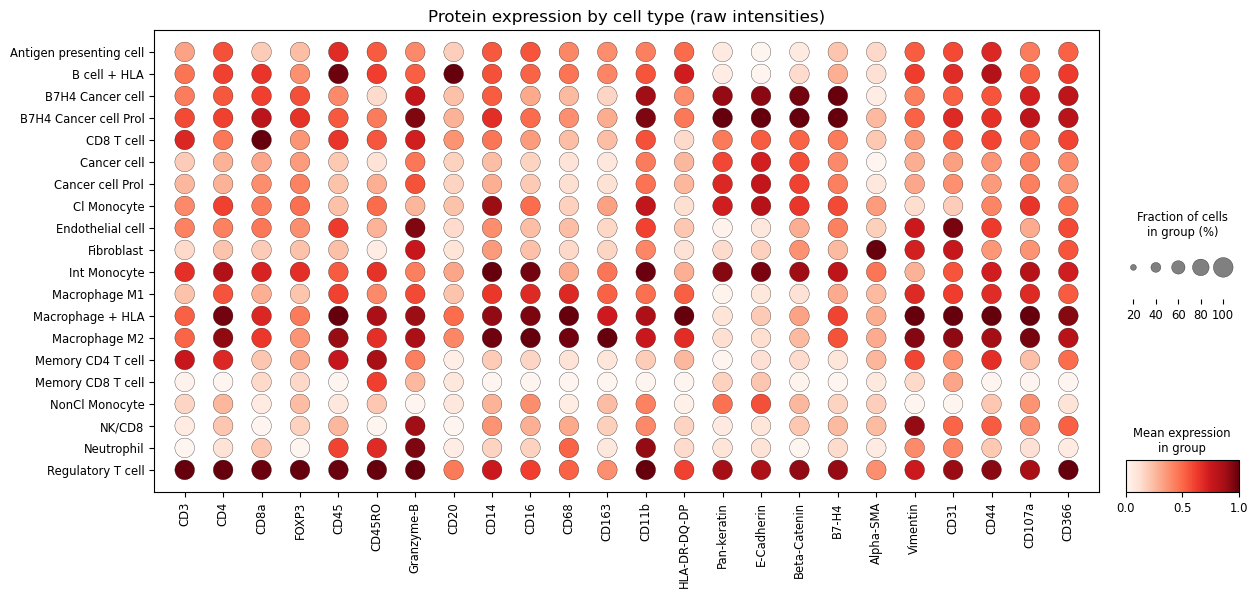

In [7]:
sc.pl.dotplot(
    adata,
    var_names=markers,
    groupby='Pixie',
    use_raw=True,
    standard_scale='var',
    title='Protein expression by cell type (raw intensities)',
    figsize=(14, 6),
    save='_protein_expression_raw.png'
)

### Matrix plot (heatmap variant)
An alternative view showing mean expression per group as a filled heatmap.

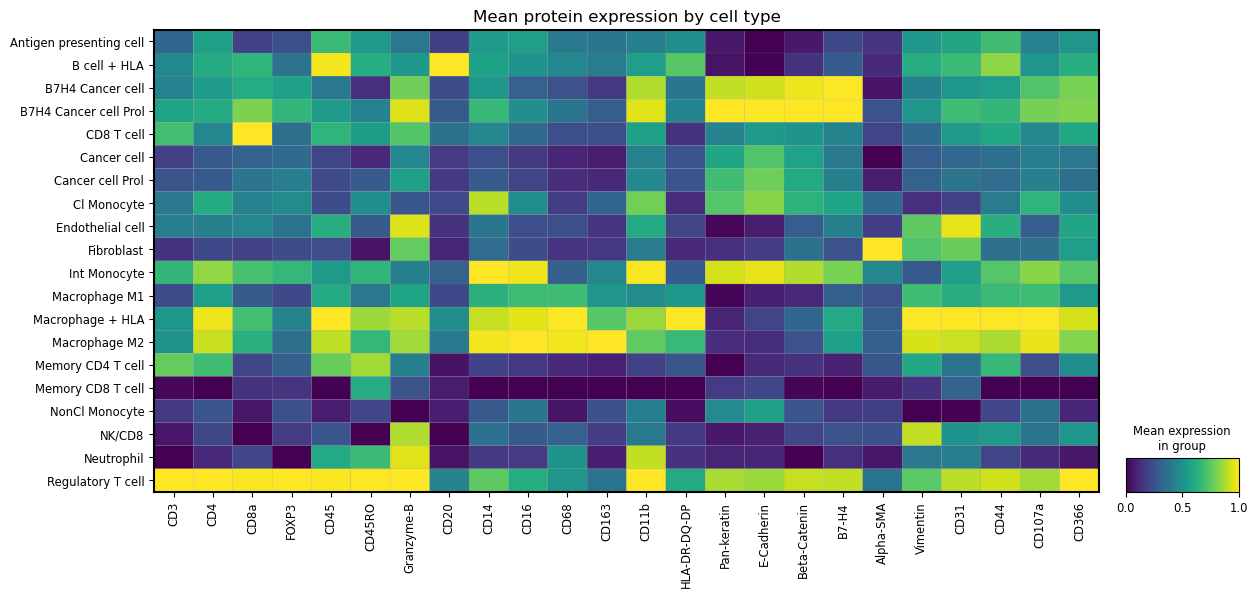

In [8]:
sc.pl.matrixplot(
    adata,
    var_names=markers,
    groupby='Pixie',
    standard_scale='var',
    title='Mean protein expression by cell type',
    figsize=(14, 6),
    save='_protein_expression_matrix.png'
)